In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
# Load joined dataset
df = pd.read_csv('../data/processed/lea_absenteeism_x_graduation_v2.csv')

recomputed = (df['chron_absent'] / df['enrolled'] * 100)
matches = np.isclose(recomputed, df['absent_rate'])

print("Shape:", df.shape)
print('Count of NaNs:', df.isna().sum())
print('Unique LEAIDs:', df['LEAID'].nunique())
print('Rows matching:', matches.sum(), 'of', len(df))
print('Max abs diff:', (recomputed - df['absent_rate']).abs().max())
assert matches.all(), "absent_rate does not match chron_absent / enrolled"
df.head()

Shape: (5940, 5)
Count of NaNs: LEAID           0
grad_rate       0
chron_absent    0
enrolled        0
absent_rate     0
dtype: int64
Unique LEAIDs: 5940
Rows matching: 5940 of 5940
Max abs diff: 1.4210854715202004e-14


,LEAID,grad_rate,chron_absent,enrolled,absent_rate
0,100005,94.0,731.0,5444.0,13.427627
1,100006,91.0,928.0,5698.0,16.286416
2,100007,94.0,1330.0,14369.0,9.256037
3,100008,96.0,1066.0,10804.0,9.866716
4,100011,95.0,241.0,2027.0,11.889492


# Verification: absent_rate is derived from chron_absent / enrolled
In this merged dataset, I've confirmed that `absent_rate` is fully derived from `chron_absent` / `enrolled` * 100, verified across all 5,940 rows, so `chron_absent` will be dropped as a model input.

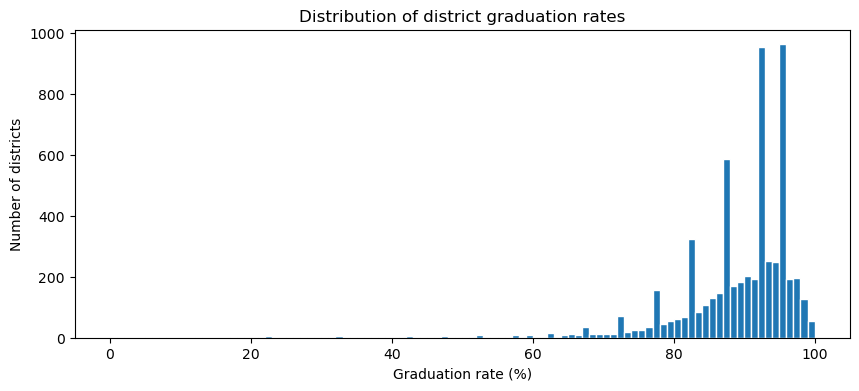

In [3]:
# Histogram plot: graduation rate vs. number of districts
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df['grad_rate'], bins=np.arange(0, 101, 1), edgecolor='white')

ax.set_xlabel('Graduation rate (%)')
ax.set_ylabel('Number of districts')
ax.set_title('Distribution of district graduation rates')
plt.show()

In [4]:
# Figure 1 data notes
print('Districts at or below 50% graduation:', (df['grad_rate'] <= 50).sum())
print(df['grad_rate'].value_counts().loc[[72, 77, 82, 87, 92, 95]])

Districts at or below 50% graduation: 76
grad_rate
72.0     71
77.0    158
82.0    324
87.0    587
92.0    956
95.0    963
Name: count, dtype: int64


# Figure 1 Notes: Graduation Rate Distribution
- `grad_rate` is left-skewed, with spikes at 72, 77, 82, 87, 92, and 95 (the tallest).
- The spikes largely reflect the suppression handling in notebook 01: ranges were replaced with their midpoints (e.g., "90-94" -> 92) and threshold codes like `GE95` with the boundary value. They are mostly imputation artifacts, not real clustering, though some districts may genuinely report those values.
- Modeling consequence: for districts reported only as `GE95`, a true 96 and a true 99 are indistinguishable in this data, so the model can't learn fine differences at the top of the range.
- The left tail is thin (76 districts at or below 50) but likely to dominate error metrics in notebook 05.

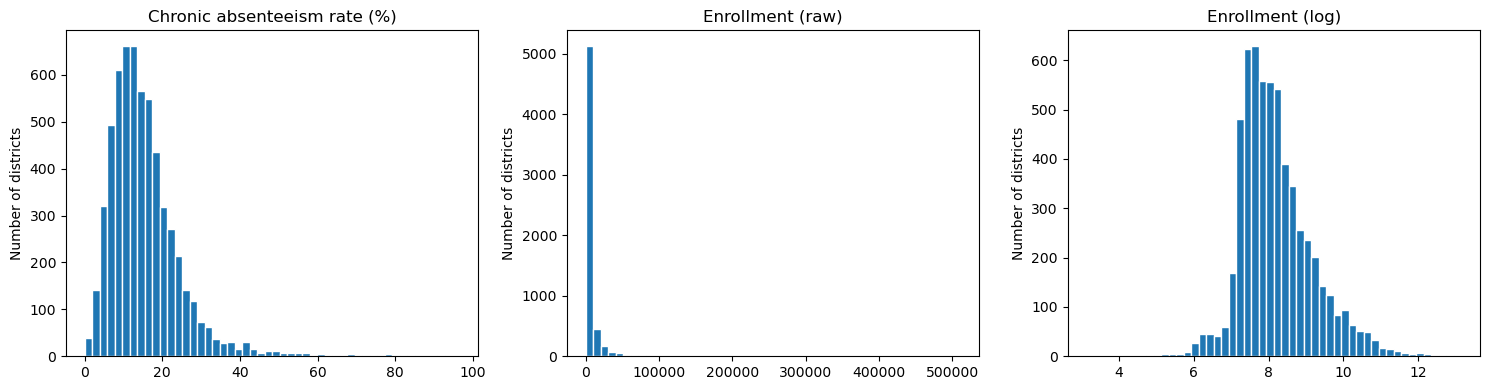

In [5]:
# Histogram plot: feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['absent_rate'], bins=50, edgecolor='white')
axes[0].set_title('Chronic absenteeism rate (%)')

axes[1].hist(df['enrolled'], bins=50, edgecolor='white')
axes[1].set_title('Enrollment (raw)')

axes[2].hist(np.log(df['enrolled']), bins=50, edgecolor='white')
axes[2].set_title('Enrollment (log)')

for ax in axes:
    ax.set_ylabel('Number of districts')

plt.tight_layout()
plt.show()

In [6]:
# Figure 2 data notes
print('absent_rate median / mean:',
      round(df['absent_rate'].median(), 1), '/', round(df['absent_rate'].mean(), 1))

counts, edges = np.histogram(df['absent_rate'], bins=50)
peak = counts.argmax()
print(f'absent_rate tallest bin: {edges[peak]:.1f}% to {edges[peak + 1]:.1f}%')

print('enrolled median / mean / max:',
      df['enrolled'].median(), round(df['enrolled'].mean()), df['enrolled'].max())
print('Share of districts under 10,000 students:',
      round((df['enrolled'] < 10000).mean(), 3))

log_median = np.log(df['enrolled']).median()
print('Median of log(enrolled):', round(log_median, 2),
      '-> back on the original scale:', round(np.exp(log_median)))

absent_rate median / mean: 13.7 / 15.6
absent_rate tallest bin: 9.7% to 11.6%
enrolled median / mean / max: 3081.5 6948 511129.0
Share of districts under 10,000 students: 0.86
Median of log(enrolled): 8.03 -> back on the original scale: 3081


# Figure 2 Notes: Feature Distributions
- `absent_rate`: right-skewed, peaking around 10-13% (median 13.7%, mean 15.6%). Usable without a transform.
- `enrolled` (raw): heavily right-skewed. Median is ~3,082 but the mean is ~6,948 and the max is 511,129; most districts fall in a single bin.
- `enrolled` (log): roughly bell-shaped, centered near 8 (about 3,000 students), so the log transform fixes the skew.
- Decision: log-transform `enrolled` if notebook 05 includes a linear model; tree-based models don't need it.

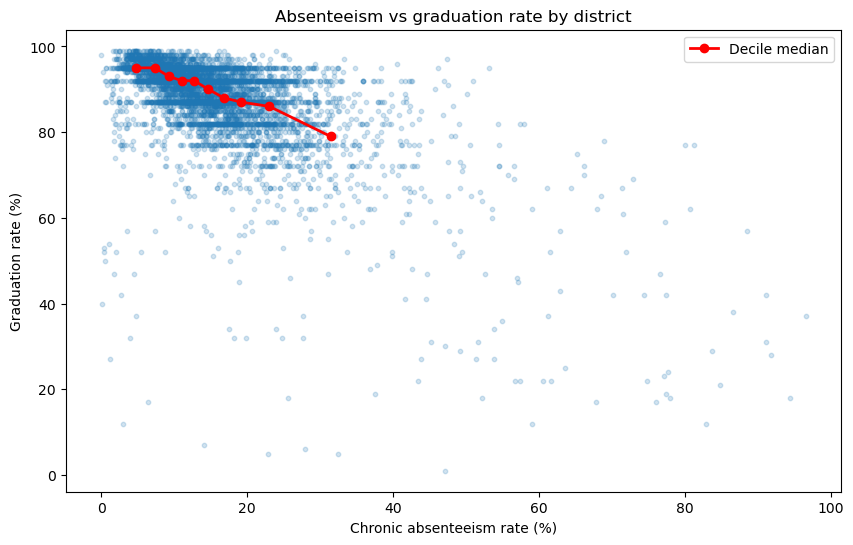

Pearson r: -0.600, r squared: 0.36


In [7]:
# Scatter plot: absent rate vs. graduation rate with binned trend line
bins = pd.qcut(df['absent_rate'], 10)

trend = df.groupby(bins, observed=True).agg(
    x=('absent_rate', 'median'),
    y=('grad_rate', 'median')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['absent_rate'], df['grad_rate'], s=10, alpha=0.2)
ax.plot(trend['x'], trend['y'], color='red', marker='o', linewidth=2, label='Decile median')

ax.set_xlabel('Chronic absenteeism rate (%)')
ax.set_ylabel('Graduation rate (%)')
ax.set_title('Absenteeism vs graduation rate by district')
ax.legend()
plt.show()

r, p = pearsonr(df['absent_rate'], df['grad_rate'])
print(f'Pearson r: {r:.3f}, r squared: {r**2:.2f}')

In [8]:
# Figure 3 data notes

# Shape: median graduation rate in each absenteeism decile
deciles = pd.qcut(df['absent_rate'], 10)
print(df.groupby(deciles, observed=True)['grad_rate'].median().round(1))

# Spread: graduation-rate variation by absenteeism band
bands = pd.cut(df['absent_rate'], [0, 10, 20, 30, 40, 100], include_lowest=True)
print(df.groupby(bands, observed=True)['grad_rate'].agg(['size', 'median', 'std']).round(1))

# Right tail
tail = df[df['absent_rate'] > 40]
print('Districts above 40% absenteeism:', len(tail))
print(tail['grad_rate'].describe().round(1))

# Unexplained cluster
cluster = df[(df['absent_rate'] < 10) & (df['grad_rate'] < 60)]
print('Low absenteeism, low graduation:', len(cluster))
print('Median enrollment: cluster', cluster['enrolled'].median(),
      'vs. all districts', df['enrolled'].median())

absent_rate
(-0.001, 6.213]     95.0
(6.213, 8.357]      95.0
(8.357, 10.197]     93.0
(10.197, 11.919]    92.0
(11.919, 13.671]    92.0
(13.671, 15.742]    90.0
(15.742, 17.926]    88.0
(17.926, 20.864]    87.0
(20.864, 25.892]    86.0
(25.892, 96.583]    79.0
Name: grad_rate, dtype: float64
                size  median   std
absent_rate                       
(-0.001, 10.0]  1727    95.0   6.7
(10.0, 20.0]    2879    91.0   6.4
(20.0, 30.0]     984    85.0   9.5
(30.0, 40.0]     199    82.0  12.7
(40.0, 100.0]    151    66.0  23.4
Districts above 40% absenteeism: 151
count    151.0
mean      60.1
std       23.4
min        1.0
25%       42.0
50%       66.0
75%       77.0
max       97.0
Name: grad_rate, dtype: float64
Low absenteeism, low graduation: 18
Median enrollment: cluster 771.5 vs. all districts 3081.5


# Figure 3 Notes: Scatter with trend line
- Direction and strength: negative, moderate relationship (Pearson r = -0.60; r squared = 0.36, so a straight line explains about a third of the variance).
- Shape: roughly flat below ~8% absenteeism (median graduation rate ~95%), then declines steadily to a median of 79% in the highest decile. A single straight line would misrepresent the flat low-absenteeism section.
- Spread: graduation-rate variance grows as absenteeism rises (std 6.7 at <= 10% vs. 23.4 above 40%), i.e., heteroscedasticity.
- Right tail: only 151 districts are above 40% absenteeism, and their graduation rates range widely (1 to 97, median 66), so the model has few examples there and predictions in that region will be unreliable.
- Unexplained cluster: 18 districts have absenteeism under 10% but graduation under 60%, and they skew small (median enrollment 771.5 vs. 3,081.5 overall). Absenteeism rate doesn't explain them.

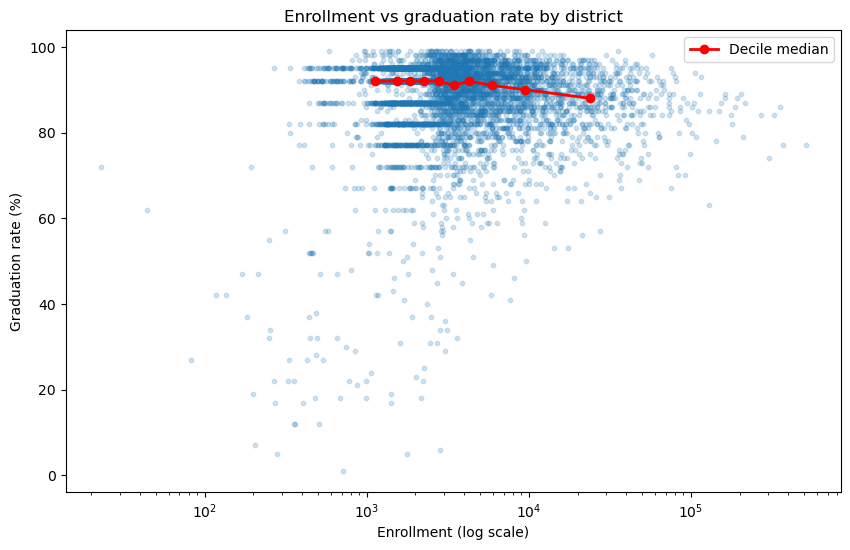

Pearson r: log enrollment 0.051, raw enrollment -0.044


In [9]:
# Scatter plot: enrollment vs. graduation rate with binned trend line
bins = pd.qcut(df['enrolled'], 10)

trend = df.groupby(bins, observed=True).agg(
    x=('enrolled', 'median'),
    y=('grad_rate', 'median')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['enrolled'], df['grad_rate'], s=10, alpha=0.2)
ax.plot(trend['x'], trend['y'], color='red', marker='o', linewidth=2, label='Decile median')
ax.set_xscale('log')

ax.set_xlabel('Enrollment (log scale)')
ax.set_ylabel('Graduation rate (%)')
ax.set_title('Enrollment vs graduation rate by district')
ax.legend()
plt.show()

r_log, _ = pearsonr(np.log(df['enrolled']), df['grad_rate'])
r_raw, _ = pearsonr(df['enrolled'], df['grad_rate'])
print(f'Pearson r: log enrollment {r_log:.3f}, raw enrollment {r_raw:.3f}')

In [10]:
# Figure 4 data notes
deciles = pd.qcut(df['enrolled'], 10)
print(df.groupby(deciles, observed=True)['grad_rate'].median())

sizes = pd.qcut(df['enrolled'], 3, labels=['small', 'mid', 'large'])
print(df.groupby(sizes, observed=True).agg(
    n=('grad_rate', 'size'),
    enr_max=('enrolled', 'max'),
    grad_median=('grad_rate', 'median'),
    grad_std=('grad_rate', 'std')
).round(1))

enrolled
(22.999, 1379.9]       92.0
(1379.9, 1691.0]       92.0
(1691.0, 2043.0]       92.0
(2043.0, 2483.6]       92.0
(2483.6, 3081.5]       92.0
(3081.5, 3850.8]       91.0
(3850.8, 5006.0]       92.0
(5006.0, 7396.0]       91.0
(7396.0, 13420.1]      90.0
(13420.1, 511129.0]    88.0
Name: grad_rate, dtype: float64
             n   enr_max  grad_median  grad_std
enrolled                                       
small     1981    2180.0         92.0      12.5
mid       1980    4518.0         92.0       9.0
large     1979  511129.0         90.0       7.7


# Figure 4 Notes: Enrollment vs. Graduation Rate
- Direction and strength: essentially no relationship (Pearson r = 0.051 with log enrollment).
- Shape: the decile medians are flat at about 92% across most of the size range, dropping only in the largest decile (13,420 students and up) to 88%.
- Spread: graduation rates are more variable in small districts than in large ones (std 12.5 for the smallest third vs. 7.7 for the largest third).
- Modeling consequence: enrollment alone is a weak predictor of graduation rate. Whether size matters in combination with absenteeism is tested in figure 5.

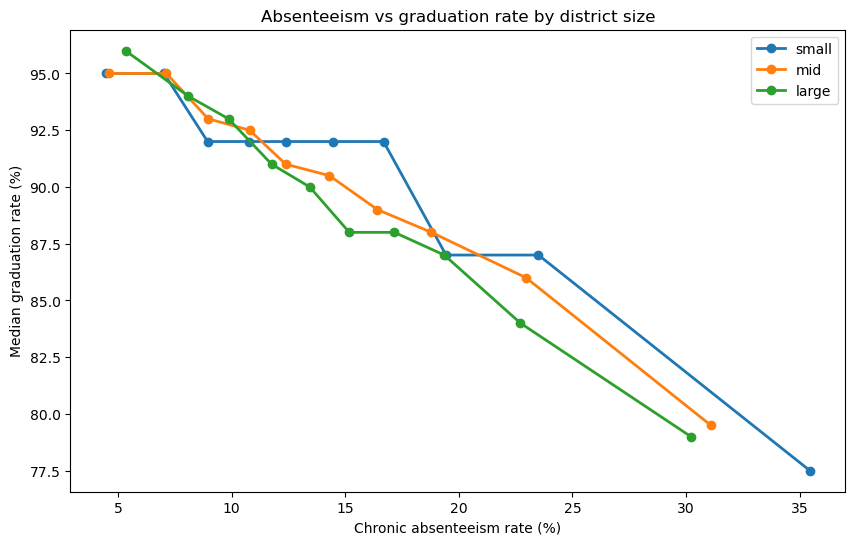

small: r = -0.604
mid: r = -0.599
large: r = -0.592


In [11]:
# Trend lines: absenteeism vs. graduation rate, by district size
sizes = pd.qcut(df['enrolled'], 3, labels=['small', 'mid', 'large'])
fig, ax = plt.subplots(figsize=(10, 6))

# Loop to create trend lines for each size group
for name in ['small', 'mid', 'large']:
    # Keep only the rows in the current size group
    subset = df[sizes == name]
    # Make absenteeism deciles inside that group
    bins = pd.qcut(subset['absent_rate'], 10)
    trend = subset.groupby(bins, observed=True).agg(
        x=('absent_rate', 'median'),
        y=('grad_rate', 'median')
    )
    ax.plot(trend['x'], trend['y'], marker='o', linewidth=2, label=name)

ax.set_xlabel('Chronic absenteeism rate (%)')
ax.set_ylabel('Median graduation rate (%)')
ax.set_title('Absenteeism vs graduation rate by district size')
ax.legend()
plt.show()

for name in ['small', 'mid', 'large']:
    subset = df[sizes == name]
    r, _ = pearsonr(subset['absent_rate'], subset['grad_rate'])
    print(f'{name}: r = {r:.3f}')

# Figure 5 Notes: Absenteeism vs. Graduation Rate by District Size
- The three size groups' trend lines are overlapping, all falling from about 95-96% graduation in the lowest-absenteeism decile to about 77.5-79.5% in the highest.
- Within-group correlations are nearly identical (small -0.604, mid -0.599, large -0.592), matching the overall r = -0.60.
- Conclusion: district size does not meaningfully change the absenteeism-graduation relationship, so this figure gives little evidence for a size-by-absenteeism interaction feature.
- Caveat: the highest-absenteeism decile in each group is the noisiest part of the data, and the small-district line reaches higher absenteeism rates than the large-district line. The flat steps in the lines reflect the clustered (imputed) graduation values from figure 1, not real plateaus.

In [12]:
# Build feature set: absent_rate + log_enrolled
features_df = pd.DataFrame({
    'LEAID': df['LEAID'],
    'absent_rate': df['absent_rate'],
    'log_enrolled': np.log(df['enrolled']),
    'grad_rate': df['grad_rate']
})

print(features_df.shape)
print(features_df.head())
print(features_df.describe().round(2))
print('NaNs:', features_df.isna().sum().sum())

(5940, 4)
    LEAID  absent_rate  log_enrolled  grad_rate
0  100005    13.427627      8.602269       94.0
1  100006    16.286416      8.647871       91.0
2  100007     9.256037      9.572828       94.0
3  100008     9.866716      9.287672       96.0
4  100011    11.889492      7.614312       95.0
            LEAID  absent_rate  log_enrolled  grad_rate
count     5940.00      5940.00       5940.00    5940.00
mean   3003036.81        15.55          8.19      88.12
std    1488087.47         9.85          0.97       9.98
min     100005.00         0.00          3.14       1.00
25%    1807890.00         9.30          7.53      86.00
50%    3302485.00        13.67          8.03      92.00
75%    4203585.00        19.22          8.69      95.00
max    7200030.00        96.58         13.14      99.00
NaNs: 0


In [13]:
# Save processed .csv file
output_path = '../data/processed/lea_features_v2.csv'
features_df.to_csv(output_path, index=False)
print(f'Saved to {output_path}')

Saved to ../data/processed/lea_features_v2.csv


# EDA Takeaways and Feature Decisions

**Target (`grad_rate`):**
- Left-skewed with spikes from suppression handling in notebook 01. Districts reported only as `GE95` could really be anywhere from 96 to 99, but the data can't tell the difference.
- 76 districts have a graduation rate at or below 50%. These will be the hardest to predict and will drive most of the model's error.

**Features kept:**
- `absent_rate`: kept as is, no transform needed. It's the strongest single predictor of `grad_rate` (r = -0.60).
- `log_enrolled`: log of `enrolled`, because raw enrollment is heavily skewed (median ~3,082, mean ~6,948, max ~511,129 — a few huge districts pull the mean way up). The log version is needed for a linear model. Tree models don't need it, but I'm using the same feature for both.

**Features dropped:**
- `chron_absent`: this is just `absent_rate` and `enrolled` multiplied back together (confirmed across all 5,940 rows), so it adds nothing new.
- `absent_rate × log_enrolled` interaction: figure 5 showed the absenteeism-graduation relationship barely changes across district sizes, so there's no real interaction to capture.
- Curved versions of `absent_rate` (like a squared term): tried this in a quick test and it barely helped. Part of the "flat" section at low absenteeism is likely just the `GE95` ceiling, not a real pattern. Not building this now — could revisit in notebook 05.

**What this sets up for notebook 05:**
- Final features: `absent_rate`, `log_enrolled`. Target: `grad_rate`, regression.
- Don't expect a high R² — only two features, and a target with real noise. A quick test got R² around 0.28, versus an error of about 10 points if you just guessed the average every time.
- The relationship isn't a straight line and gets noisier at high absenteeism (figure 3), so plan to compare a linear model against a tree-based model rather than assuming linear will be enough.